In [51]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

MY_PROJECT_ID = 'still-mesh-488107-j5'

try:
    print(f"Project in use {MY_PROJECT_ID} Extract data...")
    df_rev = pd.read_gbq(query_revenue, project_id=MY_PROJECT_ID)
    print("✅ Data read successful! Starting modeling and analysis...")

    # 1 Preprocessing
    df_rev_encoded = pd.get_dummies(df_rev, columns=['medium', 'device_category'])
    df_rev_encoded = df_rev_encoded.fillna(0)

    # 2 Preparaing X = featurs, Y = Objectives
    X = df_rev_encoded.drop(['user_pseudo_id', 'total_revenue'], axis=1)
    y = df_rev_encoded['total_revenue']

    # 3️ Train test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=180
    )

    # 4 Standarzied features
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 5 Train Model
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    # 6 Predictive Model
    y_pred = model.predict(X_test_scaled)

    # 7 Calculate R^2
    r2 = r2_score(y_test, y_pred)

    print("\n📊 Model Performance")
    print(f"R² Score: {r2:.3f}")

    # 8 Feature importance
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': model.coef_
    })

    print("\n--- Standardised Feature Importance ---")
    print(importance.sort_values(by='Coefficient', ascending=False))

except Exception as e:
    print(f"❌ The process failed:\n{e}")

Project in use still-mesh-488107-j5 Extract data...


/tmp/ipykernel_726/1653344886.py:11: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df_rev = pd.read_gbq(query_revenue, project_id=MY_PROJECT_ID)


✅ Data read successful! Starting modeling and analysis...

📊 Model Performance
R² Score: 0.246

--- Standardised Feature Importance ---
                    Feature  Coefficient
2           checkout_starts    12.273235
0             product_views     4.888698
1            cart_additions     4.612724
4     medium_(data deleted)     0.840778
7                medium_cpc     0.204098
11   device_category_mobile     0.067842
5             medium_(none)    -0.003237
10  device_category_desktop    -0.024591
9           medium_referral    -0.096437
12   device_category_tablet    -0.140960
8            medium_organic    -0.207603
6            medium_<Other>    -0.274725
3              promo_clicks    -0.594068


In [39]:
query_revenue = """
SELECT
  user_pseudo_id,
  SUM(COALESCE(event_value_in_usd, 0)) AS total_revenue,
  COUNTIF(event_name = 'view_item') AS product_views,
  COUNTIF(event_name = 'add_to_cart') AS cart_additions,
  COUNTIF(event_name = 'begin_checkout') AS checkout_starts,
  COUNTIF(event_name = 'select_promotion') AS promo_clicks,
  ANY_VALUE(traffic_source.medium) AS medium,
  ANY_VALUE(device.category) AS device_category
FROM
  `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE
  _TABLE_SUFFIX BETWEEN '20201101' AND '20210131'
GROUP BY 1
HAVING product_views > 0
"""

In [52]:
print("promo_clicks" in df_rev_encoded.columns)
print(df_rev_encoded["promo_clicks"].value_counts())

True
promo_clicks
0     56712
1      3880
2       472
3       100
4        51
5        18
6         8
7         4
12        2
9         2
16        1
24        1
8         1
Name: count, dtype: Int64


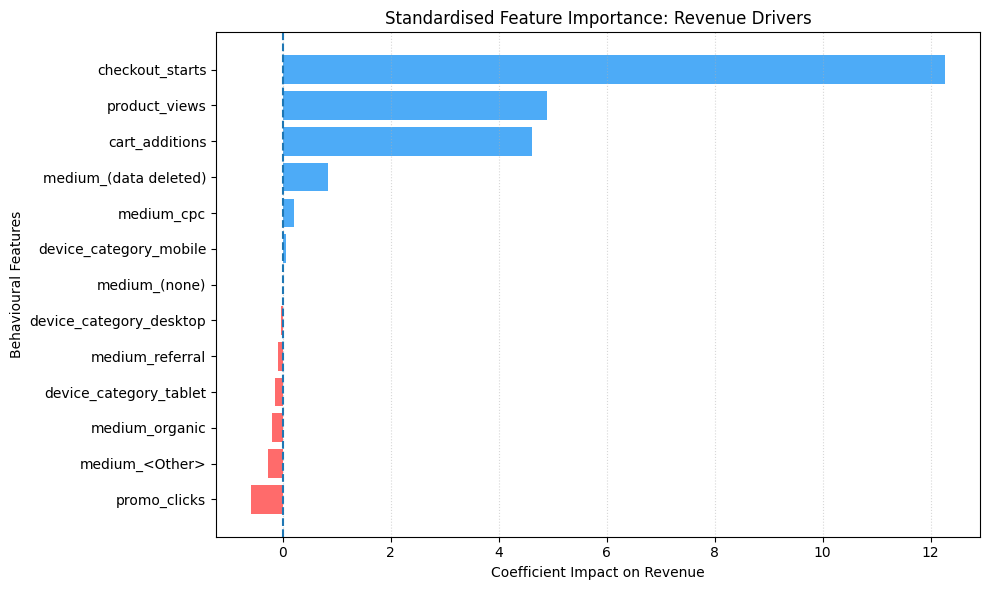

In [53]:
import matplotlib.pyplot as plt

importance_sorted = importance.sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(10,6))

colors = ['#ff6b6b' if x < 0 else '#4dabf7' for x in importance_sorted['Coefficient']]

plt.barh(
    importance_sorted['Feature'],
    importance_sorted['Coefficient'],
    color=colors
)

plt.axvline(0, linestyle='--')

plt.title("Standardised Feature Importance: Revenue Drivers")
plt.xlabel("Coefficient Impact on Revenue")
plt.ylabel("Behavioural Features")

plt.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [54]:
print(X.std().sort_values(ascending=False))

product_views              12.341266
cart_additions              3.683851
checkout_starts             2.273131
device_category_desktop      0.49316
device_category_mobile      0.488775
medium_organic              0.475939
medium_(none)               0.421609
promo_clicks                0.388714
medium_referral             0.378862
medium_<Other>              0.355809
medium_(data deleted)        0.22894
medium_cpc                  0.205384
device_category_tablet      0.149655
dtype: Float64


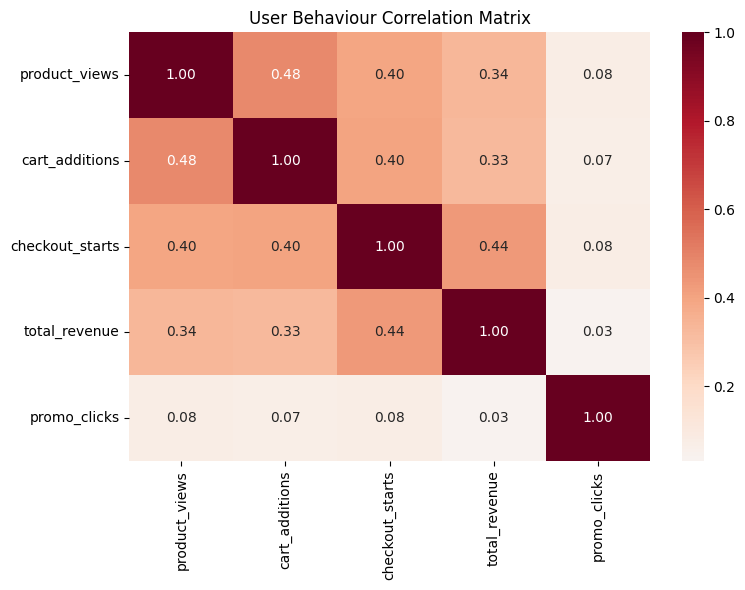

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_features = [
    "product_views",
    "cart_additions",
    "checkout_starts",
    "total_revenue",
    "promo_clicks"
]

corr_matrix = df_rev[heatmap_features].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f"
)

plt.title("User Behaviour Correlation Matrix")
plt.tight_layout()
plt.show()